# Data exploration

In [33]:
from src.lexicon_absa import LexiconABSA
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

In [48]:
file_path = '../data/test_samples_small.json'
with open(file_path, 'r') as f:
    sample_texts = json.load(f)

def collect_results(model, texts, model_name):
    rows = []
    for text in texts:
        outputs = model.analyze(text)
        for item in outputs:
            if isinstance(item, tuple):
                aspect, sentiment = item
                confidence, text_span = None, None
            else:
                aspect = item.aspect
                sentiment = item.sentiment
                confidence = getattr(item, "confidence", None)
                text_span = getattr(item, "text_span", None)

            rows.append({
                "model": model_name,
                "text": text,
                "aspect": aspect,
                "sentiment": sentiment,
                "confidence": confidence,
                "text_span": text_span
            })
    return pd.DataFrame(rows)

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x="sentiment", hue = "sentiment", palette="Set2")
    plt.title(f"{title}: Sentiment distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

## LexiconABSA Exploration
### Conceptual Overview
The LexiconABSA model is a rule-based approach that uses linguistic parsing and sentiment lexicons (e.g., VADER) to identify aspects and assign sentiment polarities.
It relies on dependency parsing and fixed dictionaries, making it fast and interpretable.
However, it can miss implicit sentiments or complex relationships between words (e.g. sarcasm).

In [49]:
lexicon_model = LexiconABSA()

for text in sample_texts:
    print(f"\n🟩 Text: {text}")
    print("→", lexicon_model.analyze(text))

df_lexicon = collect_results(lexicon_model, sample_texts, "Lexicon")


🟩 Text: The â€˜friendlyâ€™ waiter ignored us the whole night â€” amazing experience!
→ [AspectSentiment(aspect='waiter', sentiment='negative', confidence=0.398472314, text_span=(0, 25)), AspectSentiment(aspect='us', sentiment='negative', confidence=0.3182, text_span=(34, 36))]

🟩 Text: I loved the hotel location, but the room was small.
→ [AspectSentiment(aspect='room', sentiment='neutral', confidence=0.0, text_span=(32, 40)), AspectSentiment(aspect='i', sentiment='positive', confidence=0.5994, text_span=(0, 1)), AspectSentiment(aspect='hotel location', sentiment='positive', confidence=0.5994, text_span=(8, 26))]

🟩 Text: The pizza was cold and the waiter was rude.
→ [AspectSentiment(aspect='pizza', sentiment='neutral', confidence=0.0, text_span=(0, 9)), AspectSentiment(aspect='waiter', sentiment='negative', confidence=0.4588, text_span=(23, 33))]

🟩 Text: The ambience was nice and the prices were fair.
→ [AspectSentiment(aspect='ambience', sentiment='positive', confidence=0.4215, tex

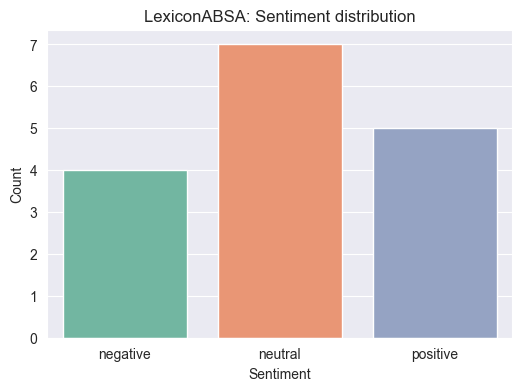

In [50]:
plot_sentiment_distribution(df_lexicon, "LexiconABSA")

### Observations

Correctly handles contextual negations (“not good” → negative).

Sometimes it misses the aspect and doesn't catch it at all if it's implicit(‘signature cocktail’ - name)

The fastest model out of all

Doesn't catch sarcasm

Sometimes doesn't catch the sentiment because the vocabulary for sentiment is too narrow (marks stale as neutral)

## TransformerABSA Exploration
### Conceptual Overview

The TransformerABSA model uses contextual embeddings from transformer architectures (e.g., RoBERTa, DeBERTa) to detect aspect terms and infer their sentiment.
Unlike rule-based methods, it learns complex language relationships and handles sarcasm, and long dependencies.
However, it requires more computational resources and is less interpretable.

In [51]:
transformer_model = TransformerABSA()

for text in sample_texts:
    print(f"\n🟦 Text: {text}")
    print("→", transformer_model.analyze(text))

df_transformer = collect_results(transformer_model, sample_texts, "Transformer")

Device set to use cpu
C:\Users\lzkol\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(



🟦 Text: The â€˜friendlyâ€™ waiter ignored us the whole night â€” amazing experience!
→ [('waiter', 'positive')]

🟦 Text: I loved the hotel location, but the room was small.
→ [('hotel', 'positive'), ('room', 'negative')]

🟦 Text: The pizza was cold and the waiter was rude.
→ [('pizza', 'negative'), ('waiter', 'negative')]

🟦 Text: The ambience was nice and the prices were fair.
→ [('ambience', 'positive'), ('prices', 'positive')]

🟦 Text: The coffee was too bitter but strong.
→ [('coffee', 'negative')]

🟦 Text: Food was not that good.
→ [('food', 'negative')]

🟦 Text: The burger was juicy, but the bun was stale and the fries were soggy.
→ [('burger', 'positive'), ('bun', 'negative'), ('fries', 'negative')]

🟦 Text: They finally fixed the air conditioning â€” about time!
→ [('air conditioning', 'neutral')]

🟦 Text: Their â€˜signature cocktailâ€™ was just juice with a fancy name.
→ [('cocktail', 'positive')]

🟦 Text: Absolutely loved the atmosphere, but the food was a disaster!
→ [('atm

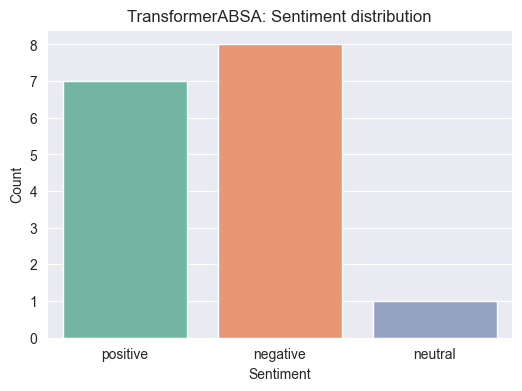

In [52]:
plot_sentiment_distribution(df_transformer, "TransformerABSA")

### Observations

Correctly handles contextual negations as well

More accurate sentiment detection but may split some phrases(hotel location - hotel).

A bit slower than lexicon model (~0.3–0.8 s per text).

Catches sarcasm (waiter - negative)

The vocabulary is wide enough to catch the sentiment of mild-difficult cases (disaster - negative)
But doesn't catch implicit difficult cases (Their ‘signature cocktail’ was just juice with a fancy name. ('cocktail', 'positive'), ('juice', 'neutral'))

LLMABSA Exploration
### Conceptual Overview

The LLMABSA implementation uses a large language model (e.g., LLaMA 3) prompted to perform aspect-based sentiment analysis in natural language.
It’s zero-shot or few-shot — meaning it doesn’t rely on fine-tuning but on prompt design.
It’s capable of handling complex, nuanced sentences but may hallucinate non-existent aspects or vary in JSON structure.

In [47]:
llm_model = LLMABSA()

for text in sample_texts:
    print(f"\n🟥 Text: {text}")
    print("→", llm_model.analyze(text))
df_llm = collect_results(llm_model, sample_texts, "LLM")


🟥 Text: The â€˜friendlyâ€™ waiter ignored us the whole night â€” amazing experience!


KeyboardInterrupt: 

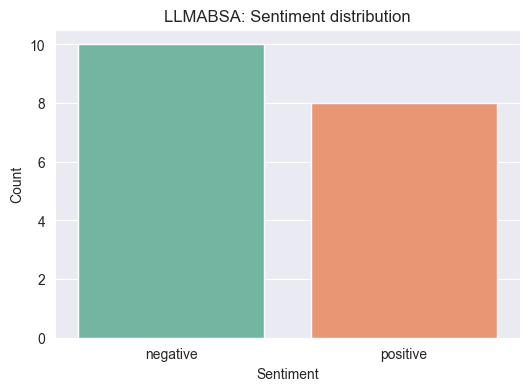

In [53]:
plot_sentiment_distribution(df_llm, "LLMABSA")

### Observations

Demonstrates strong contextual understanding and nuanced sentiment interpretation.

It correctly identifies multiple aspects per sentence,

Distinguishes between contrasting sentiments,

Handles mild implicit sentiment with impressive consistency.

However, it occasionally duplicates or overgeneralizes aspects, and it struggles with subtle sarcasm or overlapping polarities on the same entity.